# Часть 5. Анализ данных

Цель анализа - предоставить исчерпывающий анализ данных, на основе которого можно принять "правильное" бизнес-решение в сфере искусства и развлечений. Анализ призван ответить на следующий вопрос: "В какой фильм/сериал стоит вложить свои средства? Как определить "успешный" проект?".

Наша команда выделяет три метрики "успешности" проекта:

- Финансовый успех - показатель ROI
- Творческий успех - взвешенный рейтинг фильма
- Вовлеченность - число просмотренных минут зрителями, оценившими проект

Проекты с высоким ROI приносят студии финансовую прибыль, без которой ее деятельность невозможна. С другой стороны, успех продакшена — это не только кассовые сборы. Высокорейтинговые фильмы повышают статус студии, привлекают известных режиссёров и актеров, помогают получать инвестиции и определяют успех будущих проектов. Стриминг-сервисам могут быть полезны проекты с высокой вовлеченностью, поскольку для них важны просмотры, обсуждаемость и удержание аудитории.


#### Выполнили Марокина Татьяна, Соломонов Егор

In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Шаг 1. Подключение датасета

In [434]:
df = pd.read_csv("netflix_normalized_4.csv")

In [435]:
df.head(3)

,title,age_group,release_year,vote_average_imdb,vote_count_imdb,budget,revenue,runtime,genres,content_type,popularity_score,is_action,is_comedy,is_drama,is_family,is_fantasy,is_other,is_thriller,vote_count_imdb_log
0,White Chicks,teens,2004,5.9,193002.0,37000000.0,113086475.0,109.0,"Comedy, Crime",movie,91.792657,1,1,0,0,0,0,0,12.170461
1,Lucky Number Slevin,adults,2006,7.7,338824.0,27000000.0,56308881.0,110.0,"Drama, Thriller, Crime, Mystery",movie,71.922246,1,0,1,0,0,0,1,12.733239
2,Prison Break,teens,2008,8.3,670454.0,NaN,NaN,44.0,"Action, Crime, Drama",tvSeries,96.112311,1,0,1,0,0,0,0,13.415712


In [436]:
df.isna().sum()

title                    0
age_group                0
release_year             0
vote_average_imdb        0
vote_count_imdb          0
budget                 331
revenue                314
runtime                  0
genres                   0
content_type             0
popularity_score         0
is_action                0
is_comedy                0
is_drama                 0
is_family                0
is_fantasy               0
is_other                 0
is_thriller              0
vote_count_imdb_log      0
dtype: int64

## Шаг 2. Добавление ключевых признаков для анализа

Перед началом анализа создадим необходимые ключевые признаки

### 2.1 Ключевые признаки `ROI`, `weighted_rating`, `engagement`

- Признак `ROI` (Финансовый успех) Показывает рентабельность: (Доходы - Расходы) / Расходы
- Признак `weighted_rating` (Творческий успех - формула Байеса из IMDB)
- Признак `engagement` (Вовлеченность)


In [437]:
df["ROI"] = np.where(
    df["budget"] > 0, (df["revenue"] - df["budget"]) / df["budget"], np.nan
)

v = df["vote_count_imdb"]
R = df["vote_average_imdb"]
C = R.mean()
m = v.quantile(0.50)  # Порог количества голосов (медиана)
df["weighted_rating"] = (v / (v + m) * R) + (m / (v + m) * C)

df["engagement"] = np.log1p(df["runtime"] * df["vote_count_imdb"])

In [438]:
df.head(3)

,title,age_group,release_year,vote_average_imdb,vote_count_imdb,budget,revenue,runtime,genres,content_type,...,is_comedy,is_drama,is_family,is_fantasy,is_other,is_thriller,vote_count_imdb_log,ROI,weighted_rating,engagement
0,White Chicks,teens,2004,5.9,193002.0,37000000.0,113086475.0,109.0,"Comedy, Crime",movie,...,1,0,0,0,0,0,12.170461,2.056391,5.967747,16.861804
1,Lucky Number Slevin,adults,2006,7.7,338824.0,27000000.0,56308881.0,110.0,"Drama, Thriller, Crime, Mystery",movie,...,0,1,0,0,0,1,12.733239,1.085514,7.657328,17.433716
2,Prison Break,teens,2008,8.3,670454.0,NaN,NaN,44.0,"Action, Crime, Drama",tvSeries,...,0,1,0,0,0,0,13.415712,NaN,8.263697,17.199900


### 2.2 Группировки признаков для анализа

- Признак `is_movie` - фильм (1), иначе - сериал (0).
- Преобразуем признаки под нужды анализа (разбиваем на квартили) - `runtime_group` и `budget_group`
- Для жанрового анализа используем бинарные признаки напрямую (`is_action`, `is_comedy` и т.д.). Один проект может относиться к нескольким жанрам одновременно


In [439]:
df["content_type"].unique()

<StringArray>
[       'movie',     'tvSeries', 'tvMiniSeries',    'tvSpecial',
      'tvMovie',    'tvEpisode',        'video',    'videoGame']
Length: 8, dtype: str

In [440]:
df.groupby("content_type")["runtime"].agg(
    min="min",
    max="max",
    median="median",
).sort_values("median", ascending=False) # type: ignore

,min,max,median
content_type,,,
movie,25.0,136.0,91.0
tvMovie,27.0,111.0,81.0
tvSpecial,57.0,90.0,74.0
video,22.0,96.0,73.5
videoGame,60.0,60.0,60.0
tvMiniSeries,24.0,93.0,48.0
tvEpisode,44.0,59.0,45.5
tvSeries,2.0,103.0,30.0


In [441]:
df["is_movie"] = (
    df["content_type"].isin(["movie", "tvMovie", "video", "tvSpecial"]).astype(int)
)

df["runtime_group"] = pd.qcut(
    df["runtime"], q=4, labels=["Short", "Medium", "Long", "Very Long"]
)
df["budget_group"] = pd.qcut(
    df["budget"], q=4, labels=["Low", "Medium-Low", "Medium-High", "High"]
)

GENRE_COLS = [
    "is_action",
    "is_comedy",
    "is_drama",
    "is_family",
    "is_fantasy",
    "is_other",
    "is_thriller",
]

In [442]:
df.head(3)

,title,age_group,release_year,vote_average_imdb,vote_count_imdb,budget,revenue,runtime,genres,content_type,...,is_fantasy,is_other,is_thriller,vote_count_imdb_log,ROI,weighted_rating,engagement,is_movie,runtime_group,budget_group
0,White Chicks,teens,2004,5.9,193002.0,37000000.0,113086475.0,109.0,"Comedy, Crime",movie,...,0,0,0,12.170461,2.056391,5.967747,16.861804,1,Very Long,Medium-High
1,Lucky Number Slevin,adults,2006,7.7,338824.0,27000000.0,56308881.0,110.0,"Drama, Thriller, Crime, Mystery",movie,...,0,0,1,12.733239,1.085514,7.657328,17.433716,1,Very Long,Medium-High
2,Prison Break,teens,2008,8.3,670454.0,NaN,NaN,44.0,"Action, Crime, Drama",tvSeries,...,0,0,0,13.415712,NaN,8.263697,17.199900,0,Medium,NaN


## Шаг 3. "Идеальный" синтетический проект

Задача этапа: вывести синтетический "идеальный" проект с точки зрения финансов, рейтига и вовлеченности без учета скрытых взаимосвязей.

### 3.1 Синтетическая формула финансово-успешного фильма


Анализ для метрики `ROI`\
Сортируем по медиане и выводим ТОП-3


In [443]:
stats = (
    df.groupby("runtime_group")["ROI"].agg(["median", "var", "mean", "count"]).dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
runtime_group,,,,
Short,1.743078,1.444869e+01,2.899349,6
Very Long,1.383838,3.467038e+01,3.287827,79
Long,0.968565,2.890488e+11,93591.564019,33


In [444]:
stats = (
    df.groupby("budget_group")["ROI"].agg(["median", "var", "mean", "count"]).dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
budget_group,,,,
Medium-High,1.500000,3.562616,1.543217,39
Medium-Low,1.271314,11.521163,2.457777,30
High,1.246525,11.293191,2.559986,32


In [445]:
stats = df.groupby("is_movie")["ROI"].agg(["median", "var", "mean", "count"]).dropna()
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
is_movie,,,,
1,1.268335,8.593338e+10,27826.795655,111
0,1.065026,1.137485e+01,2.329490,11


In [446]:
stats = pd.DataFrame({
    col.replace("is_", ""): df[df[col] == 1]["ROI"].agg(["median", "var", "mean", "count"])
    for col in GENRE_COLS
}).T
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
comedy,1.706529,1.382406e+11,44763.452384,69.0
family,1.200587,1.163245e+11,37666.600486,82.0
thriller,1.164492,5.653908e+00,1.762833,13.0


In [447]:
stats = df.groupby("age_group")["ROI"].agg(["median", "var", "mean", "count"]).dropna()
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
age_group,,,,
teens,1.539249,1.163245e+11,37666.775225,82
adults,1.383838,3.814323e+01,3.836924,15
kids,0.743055,4.434487e+01,2.672790,25


Таким образом, синтетические идеальные проекты с точки зрения финансов:

<table style="width:70%;"> <caption>Формула проекта с высоким ROI (Финансовый успех)</caption> <thead> <th>Характеристика</th> <th>Значение</th> </thead> <tbody> <tr> <td>Жанр</td> <td>Комедия (Comedy)</td> </tr> <tr> <td>Длительность</td> <td>Очень длинные (Very Long) - от 110 минут и выше</td> </tr> <tr> <td>Бюджет</td> <td>От среднего к высокому (Medium-High)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Подростки (Teens)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Фильм</td> </tr> </tbody> </table>

_Справка: Группа "Short" для ROI показала высокую медиану, но размер выборки (всего 6 проектов) делает этот результат статистически нерелевантным. Поэтому бесспорным уверенным лидером по окупаемости являются полнометражные фильмы._


### 3.2 Синтетическая формула творчески-успешного фильма


Анализ для метрики `weighted_rating`\
Сортируем по медиане и выводим ТОП-3


In [448]:
stats = (
    df.groupby("runtime_group")["weighted_rating"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
runtime_group,,,,
Medium,7.428603,0.393911,7.401111,120
Short,6.811538,0.388714,7.147688,138
Very Long,6.691828,0.358433,6.639678,118


In [449]:
stats = (
    df.groupby("budget_group")["weighted_rating"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
budget_group,,,,
High,6.799254,0.439970,6.782856,32
Low,6.703214,0.377446,6.711963,37
Medium-High,6.674028,0.670101,6.623530,40


In [450]:
stats = (
    df.groupby("is_movie")["weighted_rating"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
is_movie,,,,
0,7.12256,0.404038,7.285466,259
1,6.67117,0.249432,6.604349,216


In [451]:
stats = pd.DataFrame({
    col.replace("is_", ""): df[df[col] == 1]["weighted_rating"].agg(["median", "var", "mean", "count"])
    for col in GENRE_COLS
}).T
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
thriller,7.260334,0.636583,7.273828,67.0
drama,7.135219,0.517388,7.215765,193.0
fantasy,6.852561,0.526079,6.933507,66.0


In [452]:
stats = (
    df.groupby("age_group")["weighted_rating"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
age_group,,,,
teens,7.003532,0.559118,7.074928,216
adults,6.876906,0.581101,7.137907,99
kids,6.750772,0.137371,6.741486,160


Таким образом, синтетические идеальные проекты с точки зрения рейтинга:

<table style="width:70%;"> <caption>Формула проекта с высоким взвешенным рейтингом (Творческий успех)</caption> <thead> <th>Характеристика</th> <th>Значение</th> </thead> <tbody> <tr> <td>Жанр</td> <td>Драма (Drama)</td> </tr> <tr> <td>Длительность</td> <td>Средние (Medium)</td> </tr> <tr> <td>Бюджет</td> <td>Высокий (High)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Подростки (Teens)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Сериал</td> </tr> </tbody> </table>


_Справка: Группа Triller показывает наивысшую медианную вовлечённость, однако насчитывает слишком мало тайтлов, чтобы вывод был статистически надёжным. Drama занимает первое место среди групп с достаточным размером выборки. Корреляционный анализ (Этап 2.2.3) указывает также на Drama как наиболее устойчивый жанровый предиктор вовлечённости по всему датасету (ρ = +0.31) — это не противоречие, а два дополняющих взгляда: медиана «что уже работало», корреляция «как жанр связан с вовлечённостью системно»._

### 3.3 Синтетическая формула фильма, вызвавшего наибольший интерес у зрителей


Анализ для метрики `engagement`\
Сортируем по медиане и выводим ТОП-3


In [453]:
stats = (
    df.groupby("runtime_group")["engagement"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
runtime_group,,,,
Very Long,15.252045,6.385459,14.551612,118
Medium,14.462053,6.419262,14.023508,120
Long,12.940259,4.801770,12.954103,99


In [454]:
stats = (
    df.groupby("budget_group")["engagement"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
budget_group,,,,
High,16.470107,1.442563,16.201262,32
Medium-High,15.984503,1.724079,15.762833,40
Medium-Low,14.723620,3.028431,14.548817,35


In [455]:
stats = (
    df.groupby("is_movie")["engagement"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
is_movie,,,,
1,14.023474,6.322614,13.743338,216
0,13.200037,8.369264,12.835169,259


In [456]:
stats = pd.DataFrame({
    col.replace("is_", ""): df[df[col] == 1]["engagement"].agg(["median", "var", "mean", "count"])
    for col in GENRE_COLS
}).T
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
fantasy,15.245131,4.474045,14.831174,66.0
thriller,15.105175,5.020602,14.695837,67.0
drama,14.863714,4.358720,14.570930,193.0


In [457]:
stats = (
    df.groupby("age_group")["engagement"]
    .agg(["median", "var", "mean", "count"])
    .dropna()
)
stats.sort_values(by="median", ascending=False).head(3)

,median,var,mean,count
age_group,,,,
teens,14.849101,4.974262,14.417988,216
adults,13.815951,5.746430,13.809783,99
kids,11.135006,6.681236,11.321349,160


Таким образом, синтетические идеальные проекты с точки зрительского интереса представлены ниже:

<table style="width:70%;"> <caption>Формула проекта с высокой вовлеченностью (Зрительский интерес)</caption> <thead> <th>Характеристика</th> <th>Значение</th> </thead> <tbody> <tr> <td>Жанр</td> <td>Драма (Drama)</td> </tr> <tr> <td>Длительность</td> <td>Очень длинные (Very Long)</td> </tr> <tr> <td>Бюджет</td> <td>Высокий (High)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Подростки (Teens)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Фильм</td> </tr> </tbody> </table>

_Справка: Группа Triller, Fantasy показывает наивысшую медианную вовлечённость, однако насчитывает слишком мало тайтлов, чтобы вывод был статистически надёжным. Drama занимает первое место среди групп с достаточным размером выборки. Корреляционный анализ (Этап 2.2.3) указывает также на Drama как наиболее устойчивый жанровый предиктор вовлечённости по всему датасету (ρ = +0.39) — это не противоречие, а два дополняющих взгляда: медиана «что уже работало», корреляция «как жанр связан с вовлечённостью системно»._


### 3.4 Промежуточные выводы


Попробуем на основе этих данных синтетически определить портрет проекта, у которого все эти метрики будут высокими:

Анализ показывает, что универсального идеального рецепта не существует — параметры финансовой окупаемости (ROI) и признания критиков/зрителей (Рейтинг) требуют разных подходов. «Комедия» лидирует по финансовой окупаемости, «Драма» — по рейтингу и по системной связи с вовлечённостью, «Триллер» — по медианной вовлечённости среди статистически надёжных групп. Целевая аудитория подростков (Teens) оказывается самой выгодной сразу по всем трём метрикам. Чтобы проект собрал кассу, удерживал внимание и получил высокие оценки, студии стоит вложиться в дорогой и длительный полнометражный фильм.

<table style="width:70%;"> <caption>Формула синтетического компромиссного «идеального» фильма</caption> <thead> <th>Характеристика</th> <th>Значение</th> </thead> <tbody> <tr> <td>Жанр</td> <td>Драма (Drama) — лидирует по рейтингу и корреляции с вовлечённостью; Триллер (Thriller), Фантастика (Fantasy) — лидирует по медианной вовлечённости</td> </tr> <tr> <td>Длительность</td> <td>Очень длинный фильм (Very Long)</td> </tr> <tr> <td>Бюджет</td> <td>Высокий (High)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Подростки (Teens / PG-13 / TV-14)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Фильм</td> </tr> </tbody> </table>


## Шаг 4. Корреляционный анализ


Задача этапа: провести _корреляционный анализ_ и определить, что влияет на выбранные метрики успешности проекта, и как они взаимосвязаны

В качестве метрики используется коэффициент Спирмена.


In [458]:
cols_to_corr = [
    "budget",
    "runtime",
    "is_movie",
    "is_action",
    "is_comedy",
    "is_drama",
    "is_family",
    "is_thriller",
    "is_other",
    "popularity_score",
]
corr_df = df[["ROI", "weighted_rating", "engagement"] + cols_to_corr].copy()
corr_df = pd.concat([corr_df, pd.get_dummies(df["age_group"], prefix="age")], axis=1)

spearman_corr = corr_df.corr(method="spearman")

### 4.1 Корреляционный анализ `ROI`

Влияние признаков на `ROI`:


In [459]:
spearman_corr[["ROI"]].sort_values(by="ROI", ascending=False)

,ROI
ROI,1.000000
engagement,0.451690
popularity_score,0.267292
is_comedy,0.195098
runtime,0.147202
age_teens,0.070404
budget,0.063047
is_movie,0.041850
age_adults,0.040755
is_thriller,-0.011692


<table style="width:70%;"> <caption>Влияние признаков на ROI</caption> <thead> <tr> <th>Признак</th> <th>Влияние на ROI</th> </tr> </thead> <tbody> <tr> <td>Жанр</td> <td>Очень слабая положительная у Comedy (+0.20); остальные - отрицательно</td> </tr> <tr> <td>Длительность</td> <td>Очень слабая положительная связь (+0.15)</td> </tr> <tr> <td>Бюджет</td> <td>Практически отсутствует (0.06)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Очень слабое: лучше у Adults (+0.04) и Teens (+0.07), хуже у Kids (−0.12)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Очень слабая положительная связь (+0.04)</td> </tr> </tbody> </table>

По результатам корреляционного анализа видно, что финансовая успешность проекта (ROI) в наибольшей степени связана с вовлеченностью аудитории: коэффициент Спирмена между `ROI и engagement составляет 0.45`, что соответствует умеренной положительной корреляции. Это означает, что проекты, вызывающие высокий интерес у зрителей, как правило, имеют и более высокую окупаемость.

### 4.2 Корреляционный анализ рейтинга фильма

Влияние признаков на Творческий рейтинг `weighted_rating`:


In [460]:
spearman_corr[["weighted_rating"]].sort_values(by="weighted_rating", ascending=False)

,weighted_rating
weighted_rating,1.000000
is_drama,0.312448
engagement,0.277005
popularity_score,0.274754
is_thriller,0.187068
age_teens,0.149172
age_adults,0.099413
budget,0.061863
is_action,0.020728
is_other,0.013054


<table style="width:70%;"> <caption>Влияние признаков на weighted_rating</caption> <thead> <tr> <th>Признак</th> <th>Влияние на weighted_rating</th> </tr> </thead> <tbody> <tr> <td>Жанр</td> <td>Слабое положительное у Drama (+0.31) и Thriller (+0.19), слабое отрицательное у Family (−0.34) и Comedy (−0.28); Action практически отсутствует (+0.02)</td> </tr> <tr> <td>Длительность</td> <td>Слабая отрицательная связь (−0.38)</td> </tr> <tr> <td>Бюджет</td> <td>Практически отсутствует (+0.06)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Слабое положительное у Adults (+0.10), отрицательное у Kids (−0.24)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Умеренная отрицательная связь (−0.55), то есть более высокие оценки чаще характерны для сериалов</td> </tr> </tbody> </table>


Для метрики `weighted_rating` наиболее сильная связь обнаружена с форматом фильм / сериал (`is_movie = −0.55`) — умеренная отрицательная корреляция. На втором месте — длительность проекта (`runtime = −0.38`), слабая отрицательная. Следовательно, более короткие проекты и, вероятно, сериалы в среднем получают более высокие оценки, чем длинные полнометражные фильмы.


### 4.3 Корреляционный анализ вовлеченности

Влияние признаков на Вовлеченность `engagement`:


In [461]:
spearman_corr[["engagement"]].sort_values(by="engagement", ascending=False)

,engagement
engagement,1.000000
popularity_score,0.764361
budget,0.618328
ROI,0.451690
is_drama,0.396382
age_teens,0.389272
runtime,0.370675
weighted_rating,0.277005
is_thriller,0.214283
is_movie,0.150991


<table style="width:70%;"> <caption>Влияние признаков на engagement</caption> <thead> <tr> <th>Признак</th> <th>Влияние на engagement</th> </tr> </thead> <tbody> <tr> <td>Жанр</td> <td>Слабое положительное у Drama (+0.39) и Thriller (+0.22), отрицательное у Family (−0.26)</td> </tr> <tr> <td>Длительность</td> <td>Слабая положительная связь (+0.37)</td> </tr> <tr> <td>Бюджет</td> <td>Умеренная положительная связь (+0.62)</td> </tr> <tr> <td>Возрастная аудитория</td> <td>Слабая положительная у Teens (+0.39), отрицательная у Kids (−0.49)</td> </tr> <tr> <td>Сериал / Фильм</td> <td>Очень слабая положительная связь (+0.15), вовлеченность незначительно выше у фильмов</td> </tr> </tbody> </table>

Метрика `engagement` демонстрирует наиболее выраженные зависимости среди всех трех показателей успеха.

Наиболее сильная положительная связь наблюдается между вовлеченностью популярностью (`popularity_score = 0.76`), а также бюджетом (`budget = 0.64`), что соответствует высокой и умеренной положительной корреляции соотвественно.
Это означает, что дорогие проекты в среднем вызывают больший интерес аудитории и собирают больше просмотренных минут. А также указывает на то, что популярность не определена временным "хайпом", а действительно отражает увлеченность зрителей.

Вторая важная связь - между `engagement` и `ROI = 0.42`. Это подтверждает, что высокий интерес аудитории в значительной степени помогает проекту быть коммерчески успешным.

### 4.4 Корреляционный анализ популярности

Определить, с какими признаками связана **популярность** контента и можно ли её использовать как косвенный предсказатель успеха.

`popularity_score` — нормализованный составной показатель [0–100]: объединяет оценку TMDB и инвертированный ранг IMDb, приведённые к единой перцентильной шкале.

In [462]:
spearman_corr[["popularity_score"]].sort_values(by="popularity_score", ascending=False)

,popularity_score
popularity_score,1.000000
engagement,0.764361
budget,0.594353
age_teens,0.289526
weighted_rating,0.274754
ROI,0.267292
is_drama,0.217605
is_action,0.209534
runtime,0.102358
is_thriller,0.100503


<table style="width:70%;"> <caption>Влияние признаков на popularity_score</caption> <thead> <tr> <th>Признак</th> <th>Влияние на popularity_score</th> </tr> </thead> <tbody> <tr> <td>Бюджет</td> <td>Сильная положительная связь: чем дороже проект, тем он популярнее</td> </tr> <tr> <td>Вовлечённость</td> <td>Сильная положительная: популярный контент дольше удерживает зрителей</td> </tr> <tr> <td>ROI</td> <td>Умеренная положительная: популярность помогает коммерческому успеху</td> </tr> <tr> <td>Жанр Drama, Action</td> <td>Положительная: драматические проекты популярнее в среднем</td> </tr> <tr> <td>Возрастная группа Teens</td> <td>Положительная: подростковый контент популярнее</td> </tr> <tr> <td>Возрастная группа Kids</td> <td>Отрицательная: детский контент менее популярен</td> </tr> <tr> <td>Жанр Family</td> <td>Отрицательная: семейные проекты уступают по популярности</td> </tr> </tbody> </table>

Посмотрим на графически на некоторые взаимосвязи

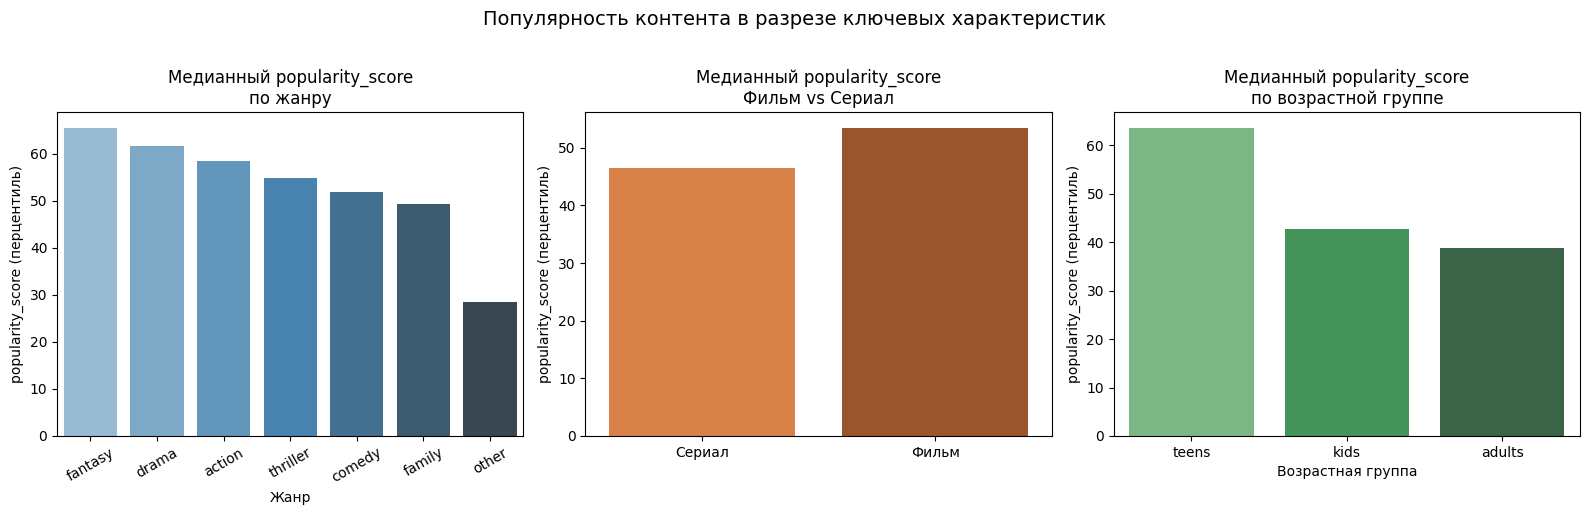

In [463]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# По жанру
genre_pop = (
    pd.Series(
        {col.replace("is_", ""): df[df[col] == 1]["popularity_score"].median()
         for col in GENRE_COLS}
    )
    .sort_values(ascending=False)
    .reset_index()
)
genre_pop.columns = ["main_genre", "popularity_score"]
sns.barplot(data=genre_pop, x="main_genre", y="popularity_score", ax=axes[0], palette="Blues_d", hue="main_genre", legend=False)
axes[0].set_title("Медианный popularity_score\nпо жанру")
axes[0].set_xlabel("Жанр")
axes[0].set_ylabel("popularity_score (перцентиль)")
axes[0].tick_params(axis="x", rotation=30)

# Фильм / сериал
type_pop = (
    df.groupby("is_movie")["popularity_score"]
    .median()
    .reset_index()
)
type_pop["label"] = type_pop["is_movie"].map({1: "Фильм", 0: "Сериал"})
sns.barplot(data=type_pop, x="label", y="popularity_score", ax=axes[1], palette="Oranges_d", hue="label", legend=False)
axes[1].set_title("Медианный popularity_score\nФильм vs Сериал")
axes[1].set_xlabel("")
axes[1].set_ylabel("popularity_score (перцентиль)")

# По возрастной группе
age_pop = (
    df.groupby("age_group")["popularity_score"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=age_pop, x="age_group", y="popularity_score", ax=axes[2], palette="Greens_d", hue="age_group", legend=False)
axes[2].set_title("Медианный popularity_score\nпо возрастной группе")
axes[2].set_xlabel("Возрастная группа")
axes[2].set_ylabel("popularity_score (перцентиль)")

plt.suptitle("Популярность контента в разрезе ключевых характеристик", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

По результатам анализа `popularity_score` можно сделать следующие выводы:

**Бюджет — ключевой драйвер популярности.** Самая сильная связь наблюдается между `popularity_score` и `budget`: дорогостоящие проекты в среднем значительно популярнее. Это подтверждает, что маркетинговые вложения и высокое качество производства напрямую влияют на охват аудитории.

**Популярность усиливает вовлечённость и ROI.** Популярный контент не только собирает больше просмотров (`engagement`), но и лучше окупается (`ROI`). Это делает популярность важным мостом между зрительским интересом и финансовым результатом.

**Жанр Drama лидирует по популярности.** Среди жанров наибольший `popularity_score` у драм — это согласуется с лидерством `Drama` по рейтингу и вовлечённости. Аудитория не только смотрит драмы, но и считает их более значимыми проектами.

**Детский контент менее популярен по аудиторному охвату.** `Kids-` и `Family-`контент уступает по `popularity_scor` e несмотря на значительную долю в датасете. Это объясняется спецификой аудитории: дети реже оставляют оценки и реже участвуют в формировании публичных рейтингов.

Включение `popularity_score` в анализ подтверждает более ранние выводы: **подростковая аудитория (teens), жанр Drama, высокий бюджет** — характеристики проекта с максимальным потенциалом охвата, что коррелирует и с финансовым успехом.

### 4.5 Влияние метрик успешности друг на друга

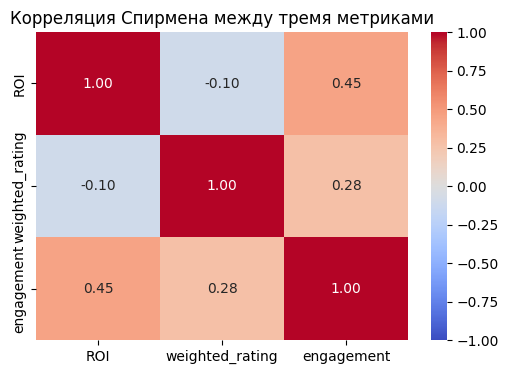

In [464]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    spearman_corr.loc[
        ["ROI", "weighted_rating", "engagement"],
        ["ROI", "weighted_rating", "engagement"],
    ],
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
)
plt.title("Корреляция Спирмена между тремя метриками")
plt.show()

<table style="width:70%;"> <caption>Корреляция между ROI, weighted_rating и engagement</caption> <thead> <tr> <th>Пара метрик</th> <th>Характер связи</th> </tr> </thead> <tbody> <tr> <td>ROI - weighted_rating</td> <td>Слабая отрицательная (−0.1)</td> </tr> <tr> <td>ROI - engagement</td> <td>Слабая положительная, близкая к умеренной (+0.45)</td> </tr> <tr> <td>weighted_rating - engagement</td> <td>Слабая положительная (+0.28)</td> </tr> </tbody> </table>

По тепловой карте корреляций между тремя метриками успешности можно сделать следующие выводы:

- Между `ROI` и `weighted_rating` наблюдается слабая отрицательная корреляция: `−0.10`.
  Это означает, что финансово успешный фильм не обязательно получает высокие зрительские оценки.

- Между `ROI` и `engagement` наблюдается слабая положительная корреляция, близкая к умеренной: `0.45`.
  Следовательно, интерес аудитории действительно помогает коммерческому успеху, хотя и не определяет его полностью.

- Между `weighted_rating` и `engagement` наблюдается слабая положительная корреляция: `0.28`.
  Это означает, что более высоко оцененные проекты в среднем вызывают больший зрительский интерес, однако связь здесь заметно слабее, чем можно было ожидать.

Делая **итоговый вывод** можно сказать следующее:
Финансовый, творческий и зрительский успех - это три разные стороны успешности проекта, которые пересекаются лишь частично.
Наиболее тесно между собой связаны ROI и engagement, то есть коммерческий успех в большей степени определяется интересом аудитории, чем высоким рейтингом. В то же время высокий рейтинг не гарантирует ни кассового успеха, ни рекордной вовлеченности.

Следовательно, при принятии бизнес-решения нельзя ориентироваться только на одну метрику.
Если студия хочет заработать, ей нужен проект с высоким потенциалом вовлечения.
Если цель - престиж и репутация, лучше делать ставку на драматический или триллерный контент.
Если приоритет - удержание зрителя на платформе, наиболее перспективны дорогие, продолжительные проекты, ориентированные на подростковую аудиторию.

## Шаг 5. Кластеризация методами ML (KMeans)

В продолжение анализа обратимся к кластеризации с целью выявления возможных скрытых взаимосвязей в данных. Выводы этапа призваны ответить на вопрос: «Какие существуют естественные группы фильмов по их характеристикам?».

*При использовании агрегированных статистик (средних значений и дисперсий) возможна потеря структуры данных, поскольку различные подгруппы наблюдений смешиваются, что может приводить к противоречивым или слабо интерпретируемым выводам. Методы кластеризации позволяют преодолеть данное ограничение за счёт выделения однородных сегментов объектов, внутри которых статистические характеристики становятся более устойчивыми и интерпретируемыми.*

In [465]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Для проведения кластеризации были отобраны признаки `runtime`, `weighted_rating`, `engagement`, `is_movie`, `is_action`, `is_comedy`, `is_drama`, `is_family`, `is_fantasy`, `is_thriller` и `is_other`, поскольку они обеспечивают наиболее полное и информативное представление о структуре данных с точки зрения их последующей бизнес-интерпретации. Выбранные переменные характеризуют как количественные аспекты контента (продолжительность, рейтинг и вовлечённость аудитории), так и его категориальные особенности (тип и жанровая принадлежность), что позволяет формировать содержательно интерпретируемые сегменты объектов.


In [466]:
cluster_features = [
    'runtime',
    'weighted_rating',
    'engagement',
    'is_movie',
    'is_action',
    'is_comedy',
    'is_drama',
    'is_family',
    'is_fantasy',
    'is_thriller',
    'is_other'
]

In [467]:
X = df[cluster_features]

In [468]:
X.dtypes

runtime            float64
weighted_rating    float64
engagement         float64
is_movie             int64
is_action            int64
is_comedy            int64
is_drama             int64
is_family            int64
is_fantasy           int64
is_thriller          int64
is_other             int64
dtype: object

Выполним стандартизацию признаков `runtime`, `weighted_rating` и `engagement` с помощью преобразователя StandardScaler. Бинарные признаки были оставлены без изменений, поскольку они уже находятся в едином масштабе.

In [469]:
scaled_features = cluster_features[:3]
X[scaled_features] = StandardScaler().fit_transform(X[scaled_features])
X.head(5)

,runtime,weighted_rating,engagement,is_movie,is_action,is_comedy,is_drama,is_family,is_fantasy,is_thriller,is_other
0,1.538857,-1.507004,1.309765,1,1,1,0,0,0,0,0
1,1.570512,1.019019,1.517054,1,1,0,1,0,0,1,0
2,-0.518750,1.925576,1.432307,0,1,0,1,0,0,0,0
3,-1.215171,1.933241,1.237508,0,0,1,1,0,0,0,0
4,-0.518750,2.058087,1.354470,0,0,0,1,0,1,1,0


Выполним обучение модели кластеризации с подбором оптимального числа кластеров `n_clusters`. Для автоматизации процесса используем цикл `for`, в рамках которого обучаются модели с различным числом кластеров. Качество кластеризации оценивается с помощью метрики `silhouette_score`, позволяющей измерить степень разделимости кластеров. По результатам сравнения выбирается конфигурация с максимальным значением метрики, которая сохраняется как оптимальная.

In [470]:
best_k = None
best_labels= None
best_score = -1
RANDOM_STATE = 67

for k in range(2, 10):
    labels = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
    ).fit_predict(X)

    score = silhouette_score(X, labels)

    if score > best_score:
        best_score = score
        best_labels = labels
        best_k = k

print(f"Лучшее число кластеров: {best_k}")
print(f"Лучший silhouette_score: {best_score:.2f}")

Лучшее число кластеров: 3
Лучший silhouette_score: 0.30


In [471]:
df['cluster'] = best_labels
df['cluster'].value_counts()

cluster
2    210
0    134
1    131
Name: count, dtype: int64

Визуализируем кластеры с помощью алгоритма `PCA`

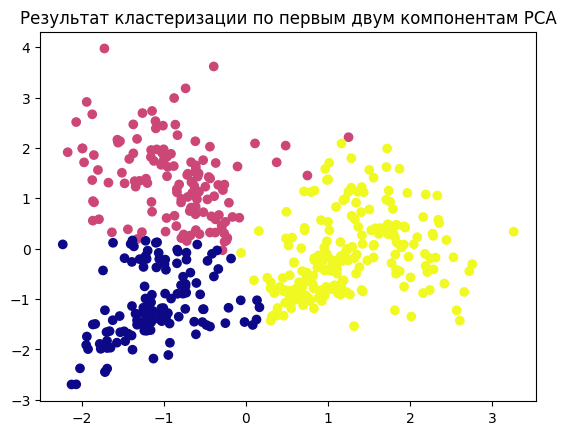

In [472]:
X_pca = PCA(n_components=2).fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap="plasma")
plt.title("Результат кластеризации по первым двум компонентам PCA")
plt.show()

Таким образом, первые две компоненты `PCA` позволяют сделать вывод о наличии некоторой структуры в кластерах. Сегменты отчетливо геометрически разделены, облака не перемешиваются между собой. С другой стороны, наблюдается тенденция к формированию единой плотной структуры, в рамках которой границы между отдельными кластерами становятся менее выраженными.

Проанализируем полученные кластеры.

In [473]:
df.groupby('cluster').agg(
    {
        'engagement': 'mean',
        'weighted_rating': 'mean',
        'runtime': 'mean',
        'is_movie': 'sum',
        'is_action': 'sum',
        'is_comedy': 'sum',
        'is_drama': 'sum',
        'is_family': 'sum',
        'is_fantasy': 'sum',
        'is_thriller': 'sum',
        'is_other': 'sum'
    }
)

,engagement,weighted_rating,runtime,is_movie,is_action,is_comedy,is_drama,is_family,is_fantasy,is_thriller,is_other
cluster,,,,,,,,,,,
0,10.407375,6.830857,27.955224,14,73,57,13,95,4,4,24
1,15.190055,7.765443,45.312977,4,54,37,103,16,20,45,8
2,13.849449,6.575558,90.485714,198,88,124,77,125,42,18,13


In [474]:
df.groupby('cluster')['age_group'].value_counts()

cluster  age_group
0        kids          93
         teens         24
         adults        17
1        teens         88
         adults        38
         kids           5
2        teens        104
         kids          62
         adults        44
Name: count, dtype: int64

Разбиение по кластерам позволяет выявить некоторое различие по смыслу. Сформируем портреты сегментов:

<table style="width: 80%;">
    <caption>Портреты сегментов, полученные благодаря кластеризации методами ML<caption>
    <thead>
        <th>Номер сегмента</th>
        <th>Портрет сегмента</th>
    </thead>
    <tbody>
        <tr>
            <td>0</td>
            <td>Сериалы. Усредненный рейтинг и самая низкая вовлеченность. Проекты с детской целевой аудиторией в жанрах Family, Comedy. </td>
        </tr>
        <tr>
            <td>1</td>
            <td>Сериалы. Наивысшие вовлеченность и рейтинг. Проекты с подростковой целевой аудиторией в жанре Drama.</td>
        </tr>
        <tr>
            <td>2</td>
            <td>Фильмы. Усредненная вовлеченность, самый низкий рейтинг. Преимущественно проекты с подростковой целевой аудиторией в жанрах Family, Comedy.</td>
        </tr>
    </tbody>
</table>

Кластеризация выявила, что пользовательская вовлеченность и оценка контента в большей степени зависят от жанровой принадлежности и целевой аудитории, чем от формата (фильм/сериал). Наиболее <u>успешным сегментом</u> являются <u>драматические сериалы</u> с <u>подростковой аудиторией</u>.

Жанры Family и Comedy плохо сочетаются с детской и подростковой аудиториями.

Выводы кластеризации частично подтверждают результаты корреляционного анализа. Это связано с тем, что признаки, используемые в кластеризации, отражают те же самые латентные факторы, которые проявились в корреляционном анализе, а именно вовлеченность аудитории, жанровую структуру и качество контента (рейтинг). С другой стороны, кластеризация выявляет целостные группы объектов, объединяя их по сходству сразу по множеству характеристик, повышая бизнес-интерпритируемость выводов.

## Шаг 6. Анализ временных рядов

В завершение анализа рассмотрим временные ряды для выявления актуальных тенденций развития индустрии развлечений.

Определим количество наблюдений для каждого года выпуска проекта. Рассмотрим актуальные данные — последние 5 лет

In [475]:
df['release_year'].value_counts().sort_index(ascending=False).head(5)

release_year
2017     33
2016    133
2015     57
2014     35
2013     31
Name: count, dtype: int64

На основе полученных результатов можно сделать вывод о несбалансированности рассматриваемых классов. Наибольшее количество наблюдений приходится на 2016 год (135 наблюдений), тогда как для остальных лет число наблюдений в 2–4 раза ниже. В связи с этим при анализе временных рядов целесообразно уделять основное внимание относительным, а не абсолютным показателям. Кроме того, ограниченный объём выборки для отдельных периодов снижает статистическую надёжность результатов и требует осторожности при интерпретации полученных выводов

Создадим отдельную переменную, хранящую информацию об актуальных проектах

In [476]:
df_time_series = df[df['release_year'] >= 2013]

Для анализа состава аудитории рассмотрим распределение проектов по возрастным группам. На рисунке представлено распределение проектов по возрастным группам в рассматриваемый период.

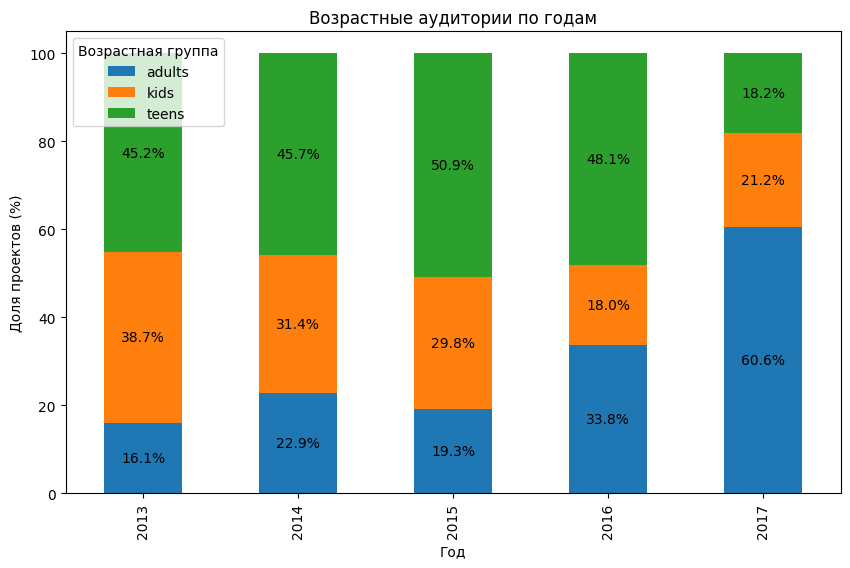

In [477]:
table = pd.crosstab(df_time_series['release_year'], df_time_series['age_group'])

table_pct = table.div(table.sum(axis=1), axis=0) * 100
 
ax = table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

for container in ax.containers:
    ax.bar_label(
        container, # type: ignore
        fmt='%.1f%%',
        label_type='center'
    )

plt.ylabel('Доля проектов (%)')
plt.xlabel('Год')
plt.title('Возрастные аудитории по годам')
plt.legend(title='Возрастная группа')
plt.show()

Таким образом, в рассматриваемом периоде наблюдается увеличение доли проектов с взрослым возрастным рейтингом с 18 % до 60 % за счёт сокращения долей остальных возрастных групп. Однако столь существенный рост может быть обусловлен выявленной ранее несбалансированностью выборки по годам. Тем не менее в период 2013–2016 гг. прослеживается устойчивая тенденция к увеличению доли проектов, ориентированных на взрослую аудиторию, что может свидетельствовать о росте их популярности.

Проекты, ориентированные на детскую аудиторию, представлены в выборке в наименьшем количестве. В конце рассматриваемого периода их доля составляет около 17–20 % от общего числа проектов. В период 2013–2016 гг. наблюдается постепенное снижение их доли, что может указывать на сокращение относительной популярности данного сегмента контента. Однако с учётом ограниченного объёма выборки полученные результаты следует интерпретировать с осторожностью.

В 2017 году доля проектов, ориентированных на подростковую аудиторию, сократилась более чем в два раза по сравнению с предыдущим годом. Однако столь резкое изменение, вероятно, связано с несбалансированностью выборки по годам и ограниченным количеством наблюдений. Если рассматривать период 2013–2016 гг., то доля подростковых проектов остаётся относительно стабильной, демонстрируя лишь незначительный рост.

Проанализируем жанровый состав выборки:

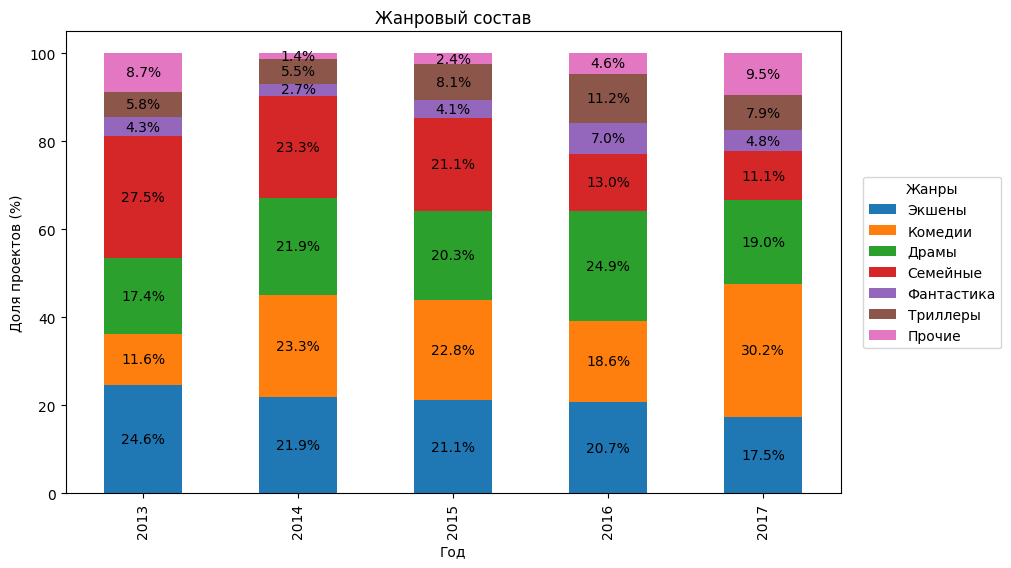

In [478]:
table = df_time_series.groupby('release_year')[
    [
        'is_action',
        'is_comedy',
        'is_drama',
        'is_family',
        'is_fantasy',
        'is_thriller',
        'is_other'
    ]
].sum()

table_pct = table.div(table.sum(axis=1), axis=0) * 100

table_pct = table_pct.rename(columns={
    'is_action': 'Экшены',
    'is_comedy': 'Комедии',
    'is_drama': 'Драмы',
    'is_family': 'Семейные',
    'is_fantasy': 'Фантастика',
    'is_thriller': 'Триллеры',
    'is_other': 'Прочие'
})

ax = table_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

ax.legend(
    title='Жанры',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

for container in ax.containers:
    ax.bar_label(
        container, # type: ignore
        fmt='%.1f%%',
        label_type='center'
    )
    
plt.ylabel('Доля проектов (%)')
plt.xlabel('Год')
plt.title('Жанровый состав')
plt.show()

Доля проектов в жанре «Семейные» демонстрирует устойчивое снижение на протяжении рассматриваемого периода — с 27,5 % до 11,1 %. Данная динамика может свидетельствовать о снижении популярности проектов данного жанра.

Проекты в жанре «Комедия» в целом стали более распространенными за рассматриваемый период, а проекты в жанре «Экшен» — менее распространенными.

«Драма» и «Фантастика» характеризуются относительной стабильностью. В рассматриваемом периоде для них не наблюдается выраженной тенденции ни к росту, ни к снижению доли в общем объёме проектов.

В период 2013–2016 гг. доля проектов в жанре «Триллер» постепенно увеличивалась. Однако в 2017 году наблюдается её резкое снижение до значения, меньшего по сравнению с предыдущими годами. С учётом выявленной несбалансированности выборки данное изменение следует интерпретировать с осторожностью.

Проанализируем динамику длительности проектов с помощью сводной таблицы:

In [479]:
df_time_series.groupby(['is_movie', 'release_year'])['runtime'].median().round(2)

is_movie  release_year
0         2013            30.0
          2014            44.5
          2015            30.0
          2016            42.5
          2017            30.0
1         2013            80.5
          2014            84.0
          2015            92.0
          2016            90.0
          2017            89.0
Name: runtime, dtype: float64

За рассматриваемый период времени медианная продолжительность сериалов практически не претерпела значительных изменений; наблюдаемые локальные колебания (скачки) могут быть связаны с неоднородностью и несбалансированностью выборки по годам наблюдения.

В то же время для фильмов отмечается слабая положительная динамика медианной продолжительности, что может указывать на постепенное увеличение хронометража в выборке.

Проанализируем отношение фильмов и сериалов за рассматриваемый период. Построим таблицу с относительными показателями.

In [480]:
temp = df_time_series.groupby(['is_movie', 'release_year'])['release_year'].count().unstack()
table = (temp.div(temp.sum(axis = 0)) * 100).round(2)

table

release_year,2013,2014,2015,2016,2017
is_movie,,,,,
0,54.84,57.14,68.42,67.67,69.7
1,45.16,42.86,31.58,32.33,30.3


За рассматриваемый период число фильмов уменьшилось, тогда как число сериалов — увеличилось.

Проанализируем динамику взвешенной оценки проектов с помощью сводной таблицы:

In [481]:
df_time_series.groupby(['release_year'])['weighted_rating'].median().round(2)

release_year
2013    6.75
2014    6.77
2015    6.80
2016    6.93
2017    6.80
Name: weighted_rating, dtype: float64

В рассматриваемый период взвешенная оценка не изменилась.

In [482]:
df_time_series.groupby(['release_year'])['engagement'].median().round(2)

release_year
2013    12.67
2014    12.96
2015    12.94
2016    13.34
2017    12.55
Name: engagement, dtype: float64

В рассматриваемый период вовлеченность не изменилась.

Сформируем итоговую таблицу с результатами анализа временных рядов:

<table style="width:70%;"> 
<caption>Результаты анализа временных рядов</caption> 
<thead> 
    <th>Характеристика</th> 
    <th>Тенденция</th> 
</thead> 
<tbody> 
<tr> 
    <td>Возрастная аудитория</td> 
    <td>Проекты для подростков (Teens) — стабильно популярны, проекты с взрослым возрастным рейтингом (Adults) — рост за последние 5 лет, проекты для детей (Kids) — низкая популярность</td> 
</tr> 
<tr> 
    <td>Жанр</td>
    <td>Семейный (Family), Экшен (Action) — падение популярности,  Драма (Drama), Фантастика (Fantasy) — стабильные показатели, Комедия (Comedy), Триллеры (Thriller) — рост</td> 
</tr> 
<tr> 
    <td> Длительность </td> 
    <td>Сериалы — показатель не претерпел изменений за рассматриваемый период, фильмы — тенденция к увеличению</td>
</tr>
<tr> 
    <td> Фильм / Сериал </td>
    <td>Сериалы — проектов стало больше, фильмы — проектов стало меньше</td>
</tr> 
<tr> 
    <td>Рейтиг</td>
    <td>Показатели не претерпели существенных изменений</td>
</tr> 
<tr> 
    <td>Вовлеченность</td> 
    <td>Показатели не претерпели существенных изменений</td>
</tr> 
</tbody> 
</table>

# Соответствие работы критериям оценивания

<ul>
    <li>Состав команды — 4 человека — Александр Гиллер, Алексей Ефимов, Татьяна Марокина, Соломонов Егор.</li>
    <li>Цель анализа — предоставить исчерпывающий анализ данных, на основе которого можно принять "правильное" бизнес-решение в сфере искусства и развлечений. Анализ призван ответить на следующий вопрос: "в какой фильм/сериал стоит вложить свои средства". Наша роль: аналитики.</li>
    <li>Критерий 1. Синтетический портрет фильма с расчетом дисперсии и медианы, корреляционный анализ, кластеризация методами ML, анализ временных рядов.</li>
    <li>Критерий 2. Цель достигнута, выводы содержатся в конце каждого подэтапа и в презентации.</li>
    <li>Критерий 3. Matplotlib. Точечный график по первым двум компонентам PCA с выделением кластеров, столбчатые диаграммы.</li>
    <li>Критерий 4. Предобработка данных была проведена — удалены дубликаты, устранены выбросы, заполнены пропуски</li>
    <li>Критерий 5. TMDB (сторонний датасет), Kaggle(сторонний датасет), IMDb(парсинг), The Numbers(парсинг). 6 новых признаков: <code>runtime</code>, <code>budget</code>, <code>revenue</code>, <code>vote_average_imdb</code>, <code>imdb_votecount</code>, <code>genres</code>,  <code>popularity_score</code>, <code>content_type</code>, 1 признак преобразован — <code>age_group</code>, 4 признака созданы в рамках feature engineering — <code>ROI</code>, <code>engagement</code>, <code>weighted_rating</code>, <code>is_movie</code> (сюда можно отнести еще признаки группы <code>is_genre</code> — 7 признаков).</li>
<ul>

# Спасибо за внимание